# Tutorial 3: Implementing risk dynamics in the GenMR digital template


**Author:** Arnaud Mignan, Mignan Risk Analytics GmbH  
**Version:** 1.2.1  
**Last Updated:** 2026-06-30  
**License:** [AGPL-3](https://opensource.org/license/agpl-v3) 

IN CONSTRUCTION - Please check back in late September 2026 for the official release.

A tutorial on catastrophe dynamics, demonstrating how to model chains-of-events and their cascading impacts.

* **v.1.2.1** (ongoing, due Sep. 2026): Implementation of the Multi-Risk Core, consisting of the modelling of chains-of-events and risk drivers within the GenMR framework (including potentially some ad-hoc parameterisations before v.1.2.3).
* **v.1.2.2** (Oct. 2026-Mar. 2027): Implementation of the generic hydropower-dam and dam flood model (led by UniL project partner) and integration into the digital template.
* **v.1.2.3** (Jan. 2027-Jun. 2027): Interaction matrix encoding, with quantitative assessment of event–event and event–environment interactions within the digital template.

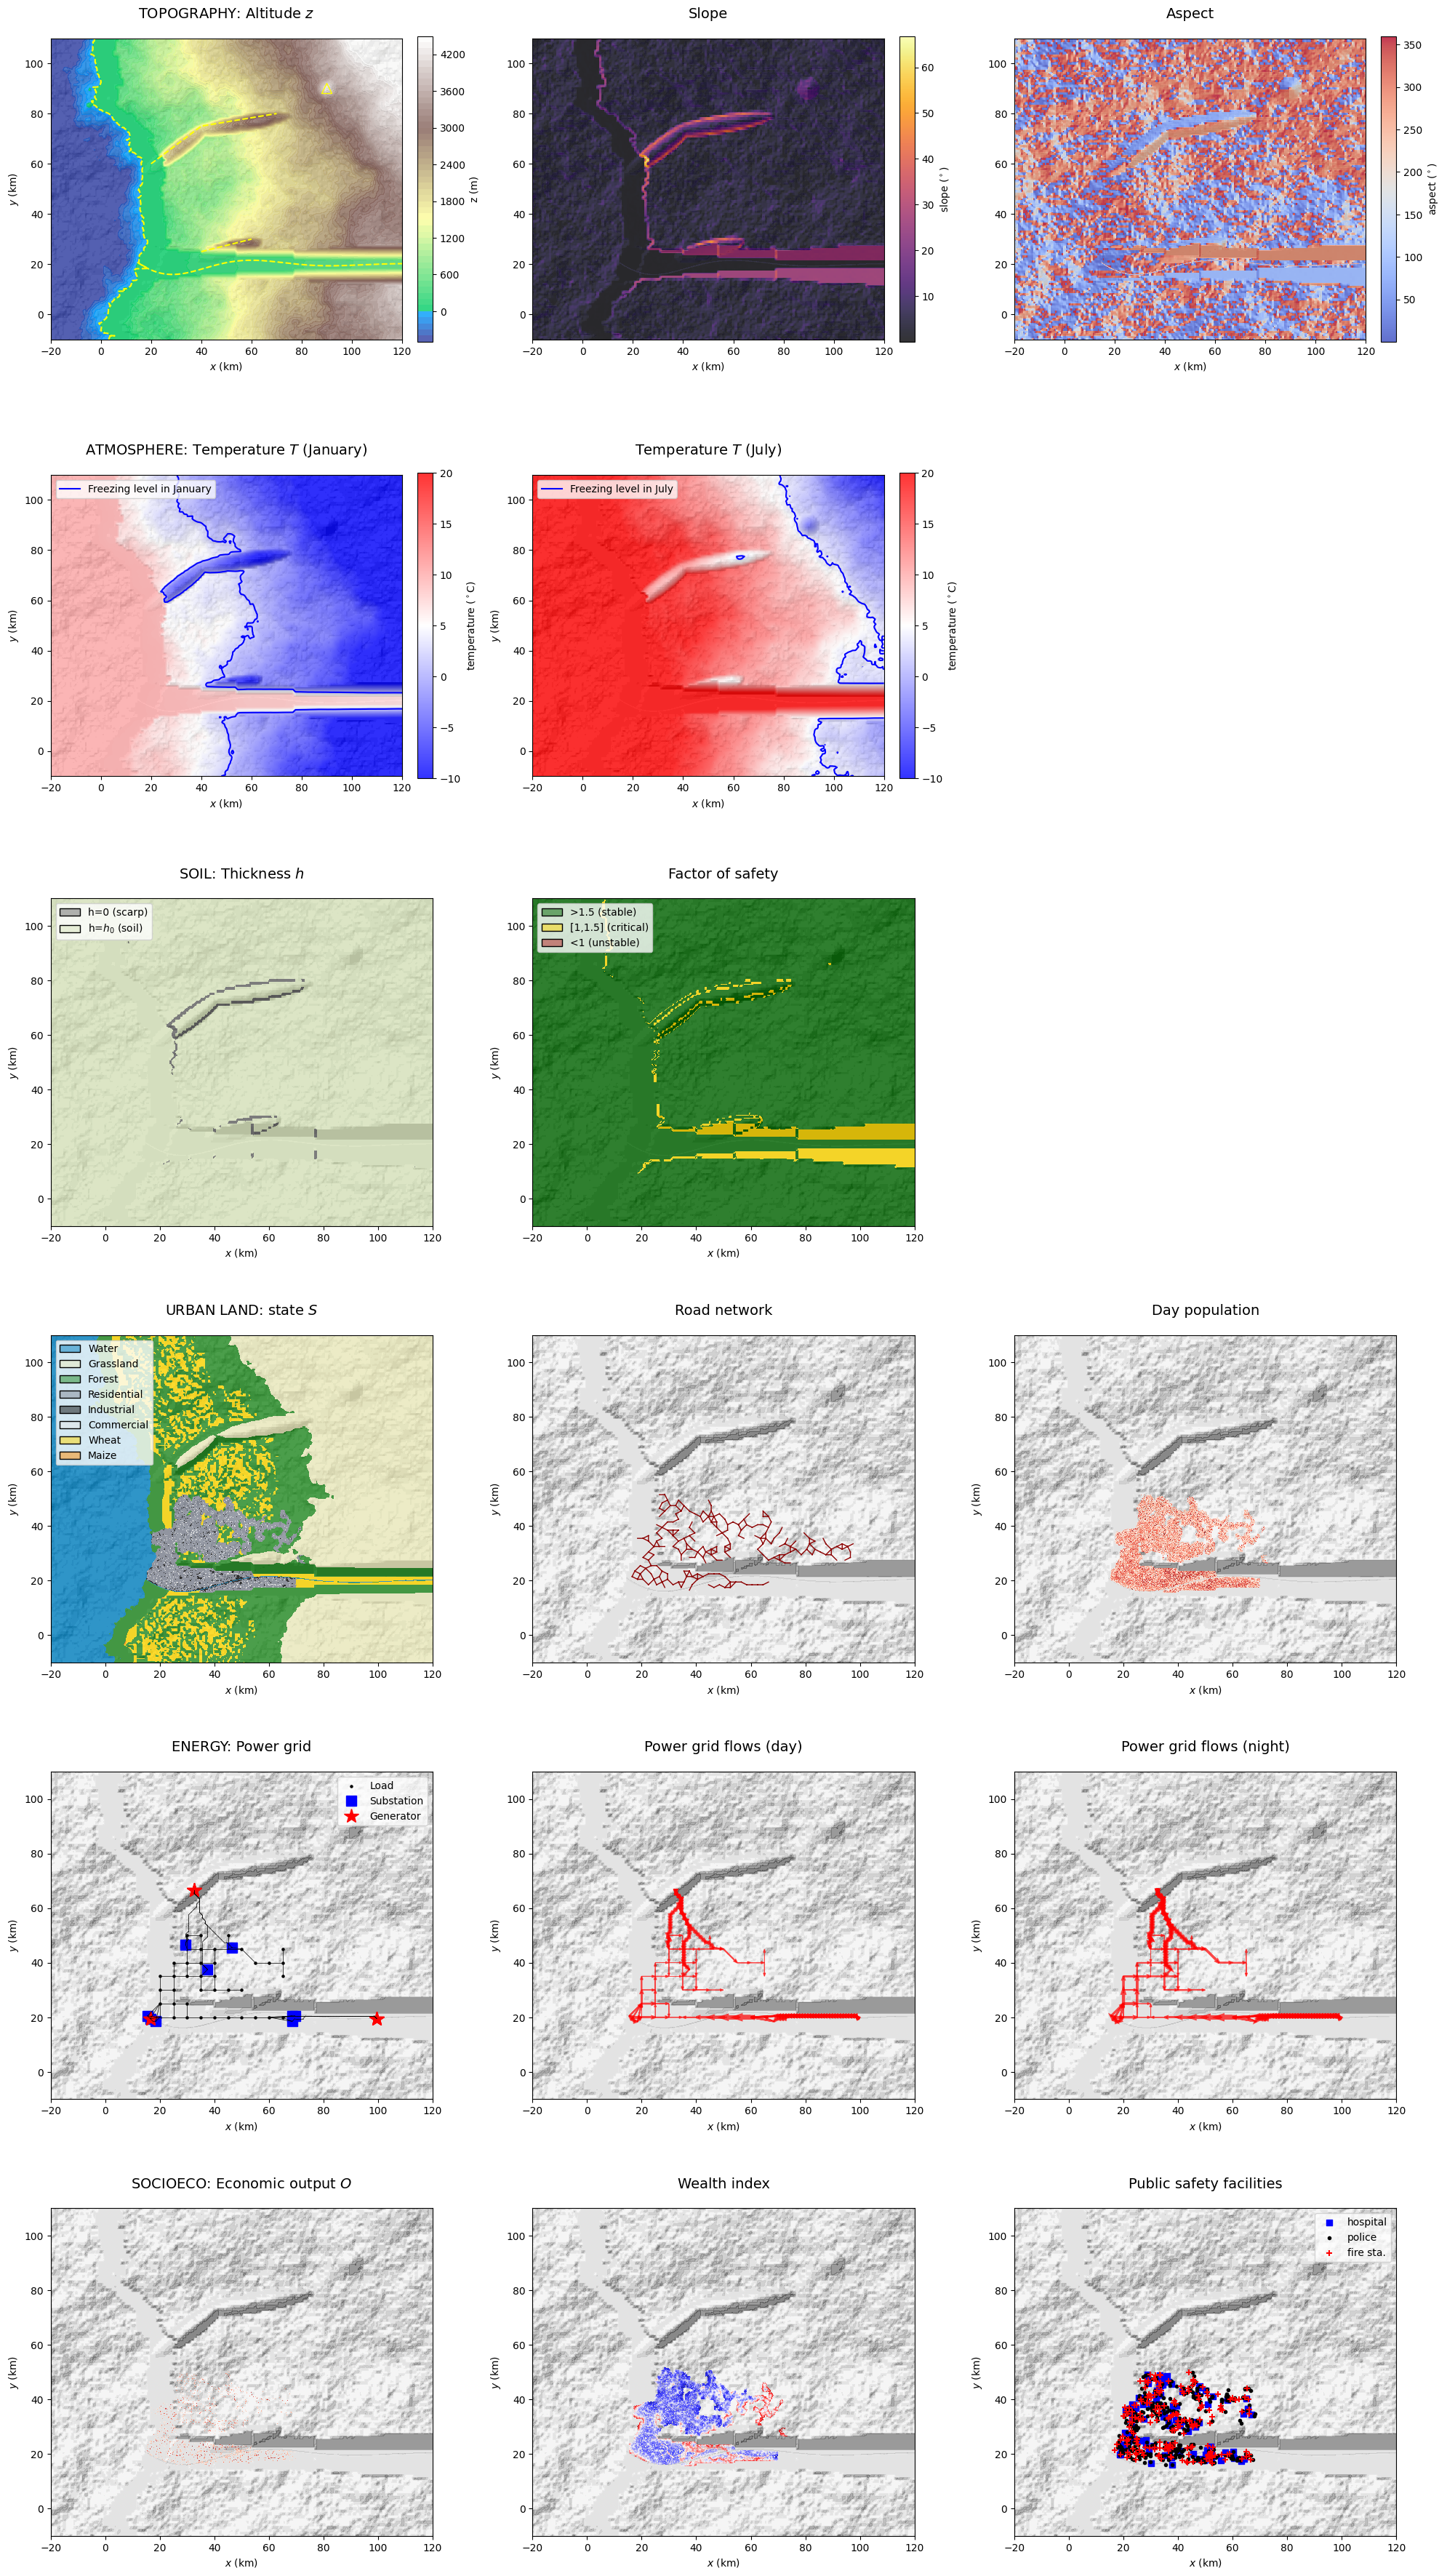

In [1]:
import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings('ignore')   # commented, try to remove all warnings

from GenMR import perils as GenMR_perils
from GenMR import environment as GenMR_env
from GenMR import dynamics as GenMR_dyn
from GenMR import utils as GenMR_utils


# load inputs (i.e., outputs from Tutorial 1)
file_src = 'src.pkl'
file_topoLayer = 'envLayer_topo.pkl'
file_atmoLayer = 'envLayer_atmo.pkl'
file_soilLayer = 'envLayer_soil.pkl'
file_urbLandLayer = 'envLayer_urbLand.pkl'
file_energyLayer = 'envLayer_energy.pkl'
file_socioecoLayer = 'envLayer_socioeco.pkl'
src = GenMR_utils.load_pickle2class('/io/' + file_src)
grid = copy.copy(src.grid)
topoLayer = GenMR_utils.load_pickle2class('/io/' + file_topoLayer)
atmoLayer = GenMR_utils.load_pickle2class('/io/' + file_atmoLayer)
soilLayer = GenMR_utils.load_pickle2class('/io/' + file_soilLayer)
urbLandLayer = GenMR_utils.load_pickle2class('/io/' + file_urbLandLayer)
energyLayer = GenMR_utils.load_pickle2class('/io/' + file_energyLayer)
socioecoLayer = GenMR_utils.load_pickle2class('/io/' + file_socioecoLayer)

GenMR_env.plot_EnvLayers([topoLayer, atmoLayer, soilLayer, urbLandLayer, energyLayer, 
                          socioecoLayer], file_ext = 'jpg', topo_bool = True)

In [2]:
# load inputs (i.e., outputs from Tutorial 2)
ELT = pd.read_parquet('io/ELT.parquet')
ELT = ELT.dropna(subset=['lbd', 'loss'])
perils = ELT['ID'].unique()

ELT

,ID,srcID,evID,S,lbd,loss
0,AI,impact1,AI1,10.000000,2.657777e-06,2.605143e+00
1,AI,impact2,AI2,10.000000,2.657777e-06,0.000000e+00
2,AI,impact3,AI3,10.000000,2.657777e-06,0.000000e+00
3,AI,impact4,AI4,100.000000,2.509457e-07,1.930789e+10
4,AI,impact5,AI5,100.000000,2.509457e-07,6.631966e+09
5,AI,impact6,AI6,100.000000,2.509457e-07,7.254955e+09
6,AI,impact7,AI7,100.000000,2.509457e-07,5.730261e+05
7,AI,impact8,AI8,1000.000000,4.212292e-08,4.193045e+06
8,AI,impact9,AI9,1000.000000,4.212292e-08,4.612970e+10
9,AI,impact10,AI10,1000.000000,4.212292e-08,1.419336e+10


## 1. Time-series modelling

### 1.1. Standard year loss table (YLT) generation

Dynamic catastrophe risk assessment requires modelling the temporal occurrence of events.

The first step is to transform the Event Loss Table (ELT; introduced in Tutorial 2) into a standard Year Loss Table (YLT), which explicitly represents the sequence of events occurring within each simulated year. This transformation is performed using the `gen_YLT()` function. The term *standard* is used to distinguish a YLT derived directly from an ELT from the more sophisticated approaches described in Section 2, where events may interact with one another and with the environment.

For each peril, an event count distribution must be specified. By default, event counts are assumed to follow a Poisson distribution, representing independent event occurrences. Alternatively, a negative binomial distribution can be used to model event clustering, as is observed for example for tropical cyclones (`TC`).

As the number of simulated years (`Nsim`) increases, the Average Annual Loss (AAL) estimated from the YLT should converge to the AAL obtained from the ELT for both count distributions. This is because the negative binomial distribution preserves the expected annual event count, while allowing for greater variability in the number of events per year.

In [84]:
## move functions to dynamics.py ##

# tmp func here...



In [5]:
Nsim = int(1e6)

AAL_ELT = np.sum(ELT['lbd'] * ELT['loss']) * 1e-6

## 1. Standard Poisson sampling
countDistr = {peril: 'Poisson' for peril in perils}
YLT_poi = GenMR_dyn.gen_YLT(ELT, Nsim, countDistr)
AAL_YLT_poi = np.sum(YLT_poi['loss']) / Nsim * 1e-6

annual_loss_poi = YLT_poi.groupby('simID')['loss'].sum().reindex(np.arange(1, Nsim+1), fill_value=0) # fill gaps
SE_poi = annual_loss_poi.std() / np.sqrt(Nsim) * 1e-6

print(f'AAL ELT (M. $): {AAL_ELT:.2f}')
print('** POISSON **')
print(f'AAL YLT Poisson (M. $): {AAL_YLT_poi:.3f} ± {2*SE_poi:.2f}  (95% CI)')
print(f'Within tolerance: {abs(AAL_ELT - AAL_YLT_poi) <= 2 * SE_poi}')

## 2. Incl. peril-based clustering option
countDistr = {peril: 'Poisson' for peril in perils}
countDistr['TC'] = 'negative binomial'             # clustering for specified perils

# overdispersion parameter: phi = var/lbd - 1 
clustering_phi = {
    'TC': .91                                      # from Mignan (2025, CUP textbook)
}

YLT_nb = GenMR_dyn.gen_YLT(ELT, Nsim, countDistr, clustering_phi)
AAL_YLT_nb = np.sum(YLT_nb['loss']) / Nsim * 1e-6

annual_loss_nb = YLT_nb.groupby('simID')['loss'].sum().reindex(np.arange(1, Nsim+1), fill_value=0)
SE_nb = annual_loss_nb.std() / np.sqrt(Nsim) * 1e-6
print('** NEGATIVE BINOMIAL (for selected perils) **')
print(f'AAL YLT nb (M. $): {AAL_YLT_nb:.3f} ± {2*SE_nb:.3f}  (95% CI)')
print(f'Within tolerance: {abs(AAL_ELT - AAL_YLT_nb) <= 2*SE_nb}')

AAL ELT (M. $): 759.92
** POISSON **
AAL YLT Poisson (M. $): 759.738 ± 11.67  (95% CI)
Within tolerance: True
** NEGATIVE BINOMIAL (for selected perils) **
AAL YLT nb (M. $): 761.601 ± 12.167  (95% CI)
Within tolerance: True


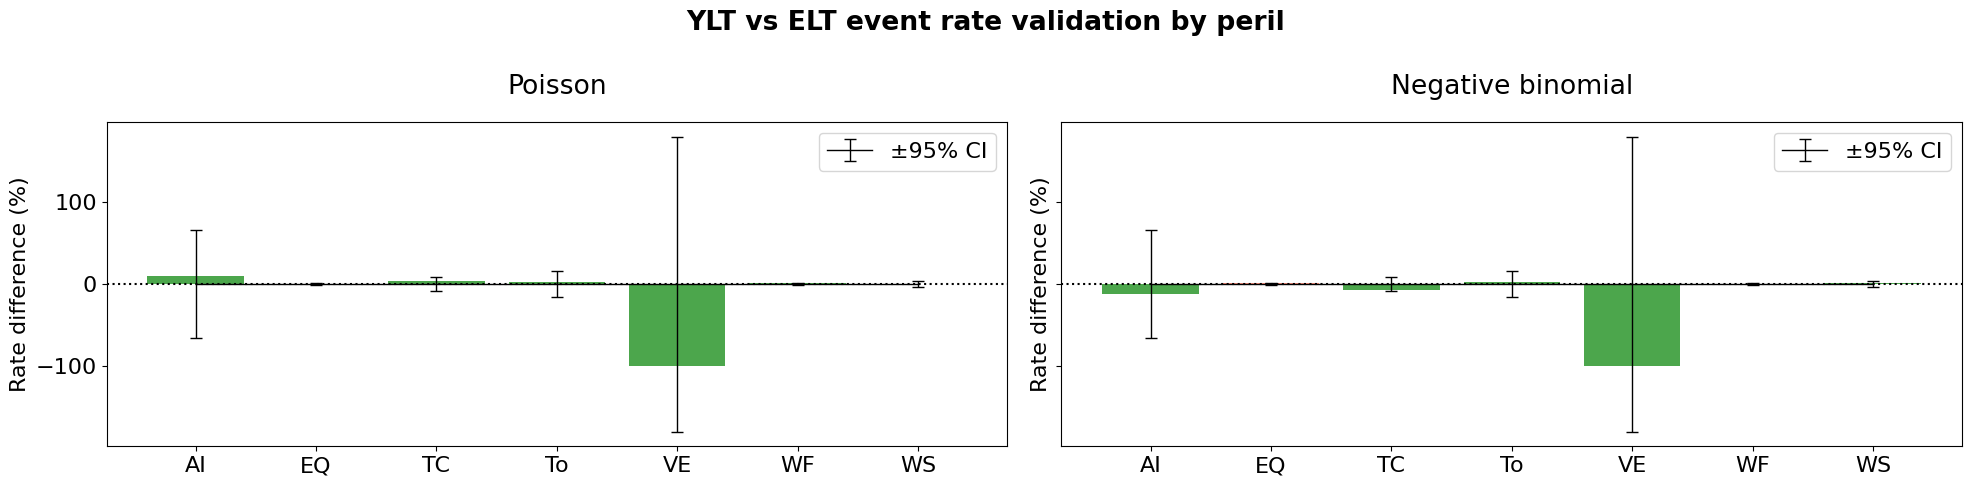

In [10]:
def validation_sim_rates(ELT, YLT, Nsim, label, ax, phi_dict = None):
    perils = ELT['ID'].unique()
    diff = []
    tol  = []
    for peril in perils:
        indperil = ELT['ID'] == peril
        lbd = ELT.loc[indperil, 'lbd'].sum()
        rate_YLT = YLT[YLT['evID'].isin(ELT.loc[indperil, 'evID'])].shape[0] / Nsim
        diff.append((rate_YLT - lbd) / lbd * 100)

        phi = phi_dict[peril] if (phi_dict and peril in phi_dict) else 0.
        tol.append(2 * np.sqrt(lbd * (1 + phi) / Nsim) / lbd * 100)          # 2 * SE

    colors = ['tomato' if abs(d) > t else 'green' for d, t in zip(diff, tol)]
    ax.bar(perils, diff, color=colors, alpha = .7)
    ax.errorbar(perils, [0] * len(perils), yerr = tol, color = 'black', capsize=4, lw=1, label='±95% CI')
    ax.axhline(0, color='black', linestyle = 'dotted')
    ax.set_ylabel('Rate difference (%)')
    ax.set_title(label, pad = 20)
    ax.legend()


plt.rcParams['font.size'] = '16'
fig, ax = plt.subplots(1, 2, figsize=(20, 5), sharey = True)
validation_sim_rates(ELT, YLT_poi, Nsim, 'Poisson', ax[0])
validation_sim_rates(ELT, YLT_nb,  Nsim, 'Negative binomial',  ax[1])
fig.suptitle('YLT vs ELT event rate validation by peril', fontweight='bold')
plt.tight_layout();

### 1.2. Seasonality implementation

ONGOING DEVELOPMENT...

## 2. Event interaction modelling

**WARNING:** Transition matrix encoding for the Digital Template environment and perils will be implemented in version 1.2.3 (Jan. 2027 – Jun. 2027).

This framework is currently under construction, using an ad hoc transition matrix for validation testing.

Note that the Year Event Table (YET), the simulated event sequence before event losses are assigned, is introduced in this section to model time series while initially avoiding the inclusion of losses that may be time-dependent or depend on previous events and environmental changes (addressed in a later section).

### 2.1. Markov process

In a first step, a Markov process is introduced into the YET generation. Non-Markovian processes (i.e., processes with memory) will be considered in Section 2.2.
